# Logistic Regression Model

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# loading cleaned preprocessed data
import joblib

try:
    data = joblib.load("/content/drive/MyDrive/AI ML/Project/Preprocessed/artifacts/preprocessed_data.pkl")
    print("Loaded from Google Drive")

except:
    data = joblib.load("artifacts/preprocessed_data.pkl")
    print("Loaded from local storage")

X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]

Loaded from Google Drive


In [22]:
# imports
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, DecisionTreeClassifier, StackingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [7]:
# balancing data for cross validation
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [13]:
# creating models
models = {"Logistic Regression": LogisticRegression(max_iter=1000),
          "Random Forest": RandomForestClassifier(n_estimators=50),
          "XGBoost": XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=6)}

In [14]:
# Training all models
results = {}
for name, model in models.items():
  scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
  results[name] = scores.mean()
  print(name, "ROC-AUC:", scores.mean())

Logistic Regression ROC-AUC: 0.9911883837483559
Random Forest ROC-AUC: 0.9999939983818492
XGBoost ROC-AUC: 0.9996966409864941


In [15]:
print(results)

{'Logistic Regression': np.float64(0.9911883837483559), 'Random Forest': np.float64(0.9999939983818492), 'XGBoost': np.float64(0.9996966409864941)}


In [16]:
# Selecting the best model
best_model_name = max(results, key=results.get)
print("Best model:", best_model_name)

Best model: Random Forest


In [17]:
# Hyper tuning the best model
param_grid = {"n_estimators": [200, 300],
              "max_depth": [4,6,8],
              "learning_rate": [0.01, 0.05, 0.1]}

grid = GridSearchCV(XGBClassifier(),
                    param_grid,
                    cv=cv,
                    scoring="roc_auc",
                    n_jobs=-1)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}


In [23]:
print(f'\n{classification_report(y_test, best_model.predict(X_test))}')
print(f'\n{confusion_matrix(y_test, best_model.predict(X_test))}')


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.78      0.79      0.78       118

    accuracy                           1.00     70932
   macro avg       0.89      0.89      0.89     70932
weighted avg       1.00      1.00      1.00     70932


[[70788    26]
 [   25    93]]


In [24]:
# Using bagging technique
bagging_model = BaggingClassifier(estimator=best_model,
                                  n_estimators=10,
                                  random_state=42)

bagging_model.fit(X_train, y_train)

BaggingClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=0.1, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=8,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=300,
                                          n_jobs=None, num_parallel_tree=None, ...),
                  random_state=42)

In [26]:
print(f'\n{classification_report(y_test, bagging_model.predict(X_test))}')
print(f'\n{confusion_matrix(y_test, bagging_model.predict(X_test))}')


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.77      0.80      0.78       118

    accuracy                           1.00     70932
   macro avg       0.89      0.90      0.89     70932
weighted avg       1.00      1.00      1.00     70932


[[70786    28]
 [   24    94]]


In [36]:
# stacking models for better performance
stack_model = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", best_model),
        ("xgb", XGBClassifier())],
    final_estimator=LogisticRegression(),
    passthrough=True)

stack_model.fit(X_train, y_train)

StackingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                               ('rf',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=Non...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(), passthrough=True)

In [38]:
y_prob = stack_model.predict_proba(X_test)[:,1]
y_pred = stack_model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.9497305665402753
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.82      0.77      0.79       118

    accuracy                           1.00     70932
   macro avg       0.91      0.89      0.90     70932
weighted avg       1.00      1.00      1.00     70932

[[70794    20]
 [   27    91]]


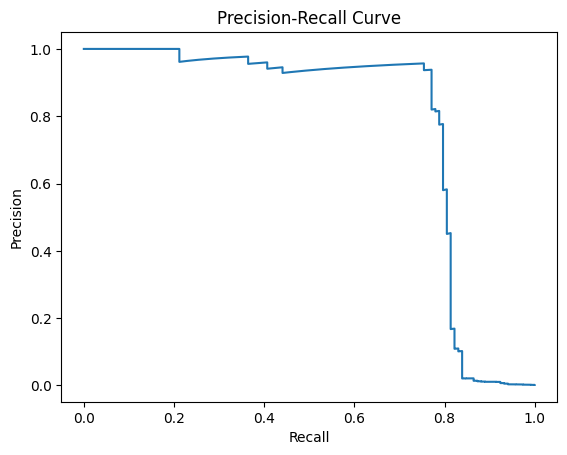

In [39]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Conclusion

### In this project, a complete machine learning pipeline was built to detect fraudulent credit card transactions. Due to the highly imbalanced dataset, **RobustScaler** and **SMOTE** were applied to improve model learning.
### Multiple models were evaluated using **Stratified Cross Validation**, and ensemble techniques such as **Random Forest and Stacking** were used to improve prediction performance.
### The final stacked model achieved strong results:
* **ROC-AUC:** 0.949
* **Precision (Fraud):** 0.82
* **Recall (Fraud):** 0.77
* **F1-Score (Fraud):** 0.79

### The **Precision-Recall curve** shows that the model maintains high precision across moderate recall levels, indicating effective detection of fraudulent transactions while keeping false positives relatively low.

### Overall, the model demonstrates strong capability in handling **imbalanced fraud detection problems** using ensemble learning and proper evaluation techniques.
